# Notebook 1 — Auth Log Anomaly Detector
## CyberAI SOC Platform — CNN + BiLSTM + Multi-Head Attention

**Dataset:** LogHub SSH (`omduggineni/loghub-ssh-log-data`)  
**Detects:** `bruteforce`, `invalid_user_scan`  
**Sessions:** Grouped by source IP  
**Output ID format:** `AUTH-{ip}`

### Architecture: CNN-BiLSTM-Attention
```
Embedding(128) 
  → Conv1D(k=3) + Conv1D(k=5) + Add + LayerNorm  [local burst detection]
  → BiLSTM(128, return_sequences=True)            [sequential order]
  → MultiHeadAttention(4 heads, key_dim=32)       [which events mattered]
  → Add + LayerNorm + GlobalAvgPool
  → Dense(256,gelu) → Dense(128,gelu) → Softmax
```

### Training stack:
- **Focal Loss** (α=0.25, γ=2.0) — handles class imbalance better than class_weight
- **Cosine Annealing Warm Restart** — principled LR cycling
- **Early stopping on macro F1** — preserves rare attack class performance
- **Mixed precision fp16** — ~2x GPU speedup
- **clipnorm=1.0** — prevents LSTM+Attention gradient explosion

## Step 1 — Environment Setup & Mixed Precision

In [2]:
%%time
!pip install drain3 --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import mixed_precision
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, Bidirectional, LSTM,
    Dense, Dropout, Add, LayerNormalization,
    GlobalAveragePooling1D, MultiHeadAttention
)
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils import resample
from drain3 import TemplateMiner
from drain3.template_miner_config import TemplateMinerConfig
import joblib, json, gc, time, os, re, math
import datetime
import warnings
warnings.filterwarnings('ignore')

# ── Mixed precision (fp16 on GPU, fp32 fallback on CPU) ─────────────────────
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print(f'Compute dtype:  {policy.compute_dtype}')
print(f'Variable dtype: {policy.variable_dtype}')

OUTPUT_PATH  = '/kaggle/working/'
SSH_LOG_PATH = '/kaggle/input/datasets/omduggineni/loghub-ssh-log-data/SSH.log'

os.makedirs(OUTPUT_PATH, exist_ok=True)

MAX_SEQ_LEN = 128
SOURCE_NAME = 'auth_log'

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

Compute dtype:  float16
Variable dtype: float32
TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
CPU times: user 33.3 ms, sys: 21.7 ms, total: 55 ms
Wall time: 3.2 s


## Step 2 — Helper Classes: FocalLoss, CosineAnnealing, MacroF1Callback

In [14]:
class FocalLoss(tf.keras.losses.Loss):
    """
    Focal Loss for multi-class classification.
    Down-weights easy (correctly classified) examples so the model focuses
    on hard minority class examples.

    alpha: prior weight (0.25 is standard from RetinaNet)
    gamma: focusing parameter. Higher = more focus on hard examples.
           gamma=0 is equivalent to cross-entropy.
           gamma=2 is the standard for security/imbalanced datasets.
    """
    def __init__(self, alpha=0.25, gamma=2.0, **kwargs):
        super().__init__(**kwargs)
        self.alpha = alpha
        self.gamma = gamma

    def call(self, y_true, y_pred):
        y_true  = tf.cast(tf.squeeze(y_true), tf.int32)
        y_pred  = tf.cast(tf.clip_by_value(y_pred, 1e-7, 1.0), tf.float32)
        n_cls   = tf.shape(y_pred)[-1]
        y_oh    = tf.one_hot(y_true, depth=n_cls, dtype=tf.float32)
        p_t     = tf.reduce_sum(y_oh * y_pred, axis=-1)
        ce      = -tf.math.log(p_t)
        focal_w = self.alpha * tf.pow(1.0 - p_t, self.gamma)
        return tf.reduce_mean(focal_w * ce)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'alpha': self.alpha, 'gamma': self.gamma})
        return cfg


class CosineAnnealingWarmRestarts(tf.keras.callbacks.Callback):
    """
    Cosine Annealing with Warm Restarts (SGDR).
    LR follows a cosine curve from initial_lr → eta_min over T_i epochs,
    then restarts. T_i doubles each cycle (T_mult=2).
    """
    def __init__(self, initial_lr=0.001, T_0=10, T_mult=2, eta_min=1e-6):
        super().__init__()
        self.initial_lr = initial_lr
        self.T_0        = T_0
        self.T_mult     = T_mult
        self.eta_min    = eta_min
        self.T_cur      = 0
        self.T_i        = T_0

    def on_epoch_begin(self, epoch, logs=None):
        lr = self.eta_min + (self.initial_lr - self.eta_min) * \
             (1 + math.cos(math.pi * self.T_cur / self.T_i)) / 2
        self.model.optimizer.learning_rate.assign(lr)
        self.T_cur += 1
        if self.T_cur >= self.T_i:
            self.T_cur = 0
            self.T_i  = int(self.T_i * self.T_mult)


class MacroF1EarlyStopping(tf.keras.callbacks.Callback):
    """
    Early stopping based on validation macro F1 score.
    Prevents the model from converging on the majority class
    at the expense of minority attack classes.
    """
    def __init__(self, X_val, y_val, patience=7, verbose=1):
        super().__init__()
        self.X_val      = X_val
        self.y_val      = y_val
        self.patience   = patience
        self.verbose    = verbose
        self.best_f1    = 0.0
        self.wait       = 0
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        y_pred   = np.argmax(self.model.predict(self.X_val, verbose=0), axis=1)
        macro_f1 = f1_score(self.y_val, y_pred, average='macro', zero_division=0)
        if self.verbose:
            print(f'  val_macro_f1: {macro_f1:.4f}  (best: {self.best_f1:.4f})')
        if macro_f1 > self.best_f1:
            self.best_f1    = macro_f1
            self.best_weights = self.model.get_weights()
            self.wait       = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.model.set_weights(self.best_weights)
                self.model.stop_training = True
                if self.verbose:
                    print(f'  Early stop — restoring best weights (macro F1={self.best_f1:.4f})')

print('✓ FocalLoss, CosineAnnealingWarmRestarts, MacroF1EarlyStopping defined')

✓ FocalLoss, CosineAnnealingWarmRestarts, MacroF1EarlyStopping defined


## Step 3 — Load Raw SSH Logs & Derive Labels

In [15]:
%%time

# SSH logs self-announce attack types — these are ground-truth signals:
BRUTEFORCE_PATTERNS = [
    r'Failed password for',
    r'authentication failure',
    r'FAILED LOGIN',
    r'Connection closed by authenticating user',
    r'Disconnecting: Too many authentication failures',
]
INVALID_USER_PATTERNS = [
    r'Invalid user',
    r'Failed password for invalid user',
    r'input_userauth_request: invalid user',
]
# FIX: Extract source IP from 'from <IP>' pattern — avoids matching server's own IP
IP_REGEX = re.compile(r'\bfrom\s+((?:\d{1,3}\.){3}\d{1,3})\b')

records = []
try:
    with open(SSH_LOG_PATH, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            ll  = line.lower()
            m   = IP_REGEX.search(line)
            src_ip = m.group(1) if m else 'UNKNOWN'

            if any(re.search(p, line, re.IGNORECASE) for p in INVALID_USER_PATTERNS):
                label = 'invalid_user_scan'
            elif any(re.search(p, line, re.IGNORECASE) for p in BRUTEFORCE_PATTERNS):
                label = 'bruteforce'
            else:
                label = 'normal'

            records.append({'raw_line': line, 'src_ip': src_ip, 'label': label})

    print(f'Loaded {len(records):,} lines from SSH.log')
except FileNotFoundError:
    raise FileNotFoundError(f'SSH.log not found at {SSH_LOG_PATH}. Mount loghub-ssh-log-data dataset.')

df_lines = pd.DataFrame(records)
print(f'\nLine-level label distribution:')
print(df_lines['label'].value_counts())
print(f'Unique source IPs: {df_lines["src_ip"].nunique():,}')

del records
gc.collect()

Loaded 655,147 lines from SSH.log

Line-level label distribution:
label
bruteforce           408408
normal               197267
invalid_user_scan     49472
Name: count, dtype: int64
Unique source IPs: 1,128
CPU times: user 8.52 s, sys: 129 ms, total: 8.65 s
Wall time: 8.63 s


1642

## Step 4 — Log Parsing with Drain3

In [16]:
%%time


def build_drain3_parser():
    config = TemplateMinerConfig()
    # config.load_defaults() <--- REMOVE THIS LINE
    
    config.drain_depth = 4
    config.drain_sim_th = 0.4
    config.drain_max_children = 100
    config.parametrize_numeric_tokens = True
    
    return TemplateMiner(config=config)

parser = build_drain3_parser()
print('Parsing with Drain3...')
t0 = time.time()
parsed = []

for i, row in df_lines.iterrows():
    parts   = row['raw_line'].split(': ', 1)
    message = parts[1] if len(parts) > 1 else row['raw_line']
    try:
        result = parser.add_log_message(message)
        tid, tmpl = result['cluster_id'], result['template_mined']
    except Exception:
        tid, tmpl = -1, '<PARSE_ERROR>'

    parsed.append({'src_ip': row['src_ip'], 'template_id': tid, 'template': tmpl,
                   'label': row['label'], 'raw_line': row['raw_line']})

    if (i + 1) % 200_000 == 0:
        print(f'  Parsed {i+1:,} lines...')

print(f'Done: {time.time()-t0:.1f}s')
df_parsed = pd.DataFrame(parsed)
print(f'Unique templates: {df_parsed["template_id"].nunique():,}')

del parsed, df_lines
gc.collect()

Parsing with Drain3...
  Parsed 200,000 lines...
  Parsed 400,000 lines...
  Parsed 600,000 lines...
Done: 33.1s
Unique templates: 47
CPU times: user 34 s, sys: 134 ms, total: 34.2 s
Wall time: 34.2 s


0

## Step 5 — Session Construction (Grouped by Source IP)

In [26]:
%%time

print('Building IP-based sessions...')
sessions = []

for src_ip, group in df_parsed.groupby('src_ip'):
    labels_in_group = group['label'].tolist()
    event_seq       = group['template_id'].tolist()

    # FIX: count-based thresholds instead of any-match
    # prevents mislabeling legitimate users who had 1-2 failed logins
    bruteforce_count    = sum(1 for l in labels_in_group if l == 'bruteforce')
    invalid_user_count  = sum(1 for l in labels_in_group if l == 'invalid_user_scan')
    total_events        = len(labels_in_group)

    if bruteforce_count >= 3:
        session_label = 'bruteforce'
    elif invalid_user_count >= 2:
        session_label = 'invalid_user_scan'
    else:
        session_label = 'normal'

    sessions.append({
        'session_id': str(src_ip),
        'src_ip':     str(src_ip),
        'event_seq':  event_seq,
        'n_events':   total_events,
        'label':      session_label,
        'raw_lines':  group['raw_line'].tolist()
    })

df_sessions = pd.DataFrame(sessions)
del sessions
gc.collect()

print(f'Total sessions: {len(df_sessions):,}')
print(f'Label distribution:')
print(df_sessions['label'].value_counts())
print(f'\nSession length stats:')
print(df_sessions['n_events'].describe())

Building IP-based sessions...
Total sessions: 1,128
Label distribution:
label
invalid_user_scan    453
normal               392
bruteforce           283
Name: count, dtype: int64

Session length stats:
count      1128.000000
mean        580.804078
std       11802.681838
min           1.000000
25%           2.000000
50%           5.000000
75%          19.000000
max      392787.000000
Name: n_events, dtype: float64
CPU times: user 655 ms, sys: 18.7 ms, total: 674 ms
Wall time: 670 ms


## Step 6 — Label Normalization & Encoding

In [27]:
%%time

MASTER_LABEL_MAP = {
    'normal':           'normal',
    'bruteforce':       'bruteforce',
    'brute_force':      'bruteforce',
    'invalid_user_scan':'invalid_user_scan',
    'invalid_user':     'invalid_user_scan',
    'scan':             'invalid_user_scan',
}

df_sessions['unified_label'] = df_sessions['label'].apply(
    lambda x: MASTER_LABEL_MAP.get(str(x).lower().strip(), 'bruteforce')
)

ALL_CLASSES = sorted(df_sessions['unified_label'].unique())
NUM_CLASSES = len(ALL_CLASSES)
print(f'Classes: {ALL_CLASSES}')

master_le = LabelEncoder()
master_le.fit(ALL_CLASSES)
df_sessions['label_enc'] = master_le.transform(df_sessions['unified_label'])

joblib.dump(master_le, OUTPUT_PATH + 'label_encoder.pkl')
with open(OUTPUT_PATH + 'label_map.json', 'w') as f:
    json.dump(MASTER_LABEL_MAP, f, indent=2)
print('✓ label_encoder.pkl, label_map.json saved')

Classes: ['bruteforce', 'invalid_user_scan', 'normal']
✓ label_encoder.pkl, label_map.json saved
CPU times: user 6.37 ms, sys: 47 µs, total: 6.42 ms
Wall time: 5.13 ms


## Step 7 — Vocabulary

In [28]:
%%time

all_template_ids = sorted(df_parsed['template_id'].unique())
vocab      = {tid: idx + 1 for idx, tid in enumerate(all_template_ids)}
VOCAB_SIZE = len(vocab) + 1
print(f'Vocabulary size: {VOCAB_SIZE} templates')

joblib.dump(vocab, OUTPUT_PATH + 'vocab.pkl')
with open(OUTPUT_PATH + 'feature_names.txt', 'w') as f:
    for tid in all_template_ids:
        rows = df_parsed[df_parsed['template_id'] == tid]
        tmpl = rows['template'].iloc[0][:80] if len(rows) > 0 else '<EMPTY>'
        f.write(f'{tid}\t{tmpl}\n')
print('✓ vocab.pkl, feature_names.txt saved')

Vocabulary size: 48 templates
✓ vocab.pkl, feature_names.txt saved
CPU times: user 127 ms, sys: 822 µs, total: 128 ms
Wall time: 126 ms


## Step 8 — 3% Inference Holdout + 80/20 Split

In [29]:
%%time

def encode_session(event_seq, vocab, max_len=MAX_SEQ_LEN):
    return [vocab.get(eid, VOCAB_SIZE) for eid in event_seq][:max_len]

# ── 3% holdout (stratified, no leakage) ──────────────────────────────────────
inf_dfs, remaining_dfs = [], []
for cls in ALL_CLASSES:
    cls_data = df_sessions[df_sessions['unified_label'] == cls].copy()
    n_inf    = max(int(len(cls_data) * 0.03), 5)
    if len(cls_data) <= n_inf:
        inf_sample = resample(cls_data, n_samples=n_inf, random_state=42, replace=True)
        remaining  = cls_data
    else:
        inf_sample = cls_data.sample(n=n_inf, random_state=42)
        remaining  = cls_data.drop(inf_sample.index)
    print(f'  [{cls}] total={len(cls_data)}, inference={n_inf}, remaining={len(remaining)}')
    inf_dfs.append(inf_sample)
    remaining_dfs.append(remaining)

df_inference = pd.concat(inf_dfs).reset_index(drop=True)
df_remaining = pd.concat(remaining_dfs).reset_index(drop=True)
assert len(set(ALL_CLASSES) - set(df_inference['unified_label'].unique())) == 0
print(f'\nInference holdout: {len(df_inference)} sessions')
print(f'Remaining for train/test: {len(df_remaining)} sessions')

# ── FIX: oversample normal class before split ─────────────────────────────────
label_counts  = df_remaining['unified_label'].value_counts()
print(f'\nBefore oversampling:\n{label_counts}')

normal_df     = df_remaining[df_remaining['unified_label'] == 'normal']
majority_n    = label_counts.max()
target_normal = max(int(majority_n * 0.5), len(normal_df))  # at least 50% of majority

if len(normal_df) < target_normal:
    normal_upsampled = resample(
        normal_df,
        n_samples=target_normal,
        random_state=42,
        replace=True
    )
    df_remaining = pd.concat([
        df_remaining[df_remaining['unified_label'] != 'normal'],
        normal_upsampled
    ]).sample(frac=1, random_state=42).reset_index(drop=True)
    print(f'\nAfter oversampling normal to {target_normal}:')
    print(df_remaining['unified_label'].value_counts())
else:
    print('\nNormal class sufficient — no oversampling needed.')

# ── Re-encode labels after oversampling ──────────────────────────────────────
df_remaining['label_enc'] = master_le.transform(df_remaining['unified_label'])

# ── 80/20 train/test split ────────────────────────────────────────────────────
X_raw = df_remaining['event_seq'].tolist()
y_enc = df_remaining['label_enc'].values
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_enc, test_size=0.20, random_state=42, stratify=y_enc
)

X_train = pad_sequences(
    [encode_session(s, vocab) for s in X_train_raw],
    maxlen=MAX_SEQ_LEN, padding='post', truncating='post'
)
X_test = pad_sequences(
    [encode_session(s, vocab) for s in X_test_raw],
    maxlen=MAX_SEQ_LEN, padding='post', truncating='post'
)
X_inf = pad_sequences(
    [encode_session(row['event_seq'], vocab) for _, row in df_inference.iterrows()],
    maxlen=MAX_SEQ_LEN, padding='post', truncating='post'
)
y_inf = master_le.transform(df_inference['unified_label'])

print(f'\nFinal shapes:')
print(f'  X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'  X_test:  {X_test.shape}   y_test:  {y_test.shape}')
print(f'  X_inf:   {X_inf.shape}    y_inf:   {y_inf.shape}')

del X_raw, X_train_raw, X_test_raw
gc.collect()

  [bruteforce] total=283, inference=8, remaining=275
  [invalid_user_scan] total=453, inference=13, remaining=440
  [normal] total=392, inference=11, remaining=381

Inference holdout: 32 sessions
Remaining for train/test: 1096 sessions

Before oversampling:
unified_label
invalid_user_scan    440
normal               381
bruteforce           275
Name: count, dtype: int64

Normal class sufficient — no oversampling needed.

Final shapes:
  X_train: (876, 128)  y_train: (876,)
  X_test:  (220, 128)   y_test:  (220,)
  X_inf:   (32, 128)    y_inf:   (32,)
CPU times: user 380 ms, sys: 3.61 ms, total: 384 ms
Wall time: 381 ms


0

## Step 9 — EDA

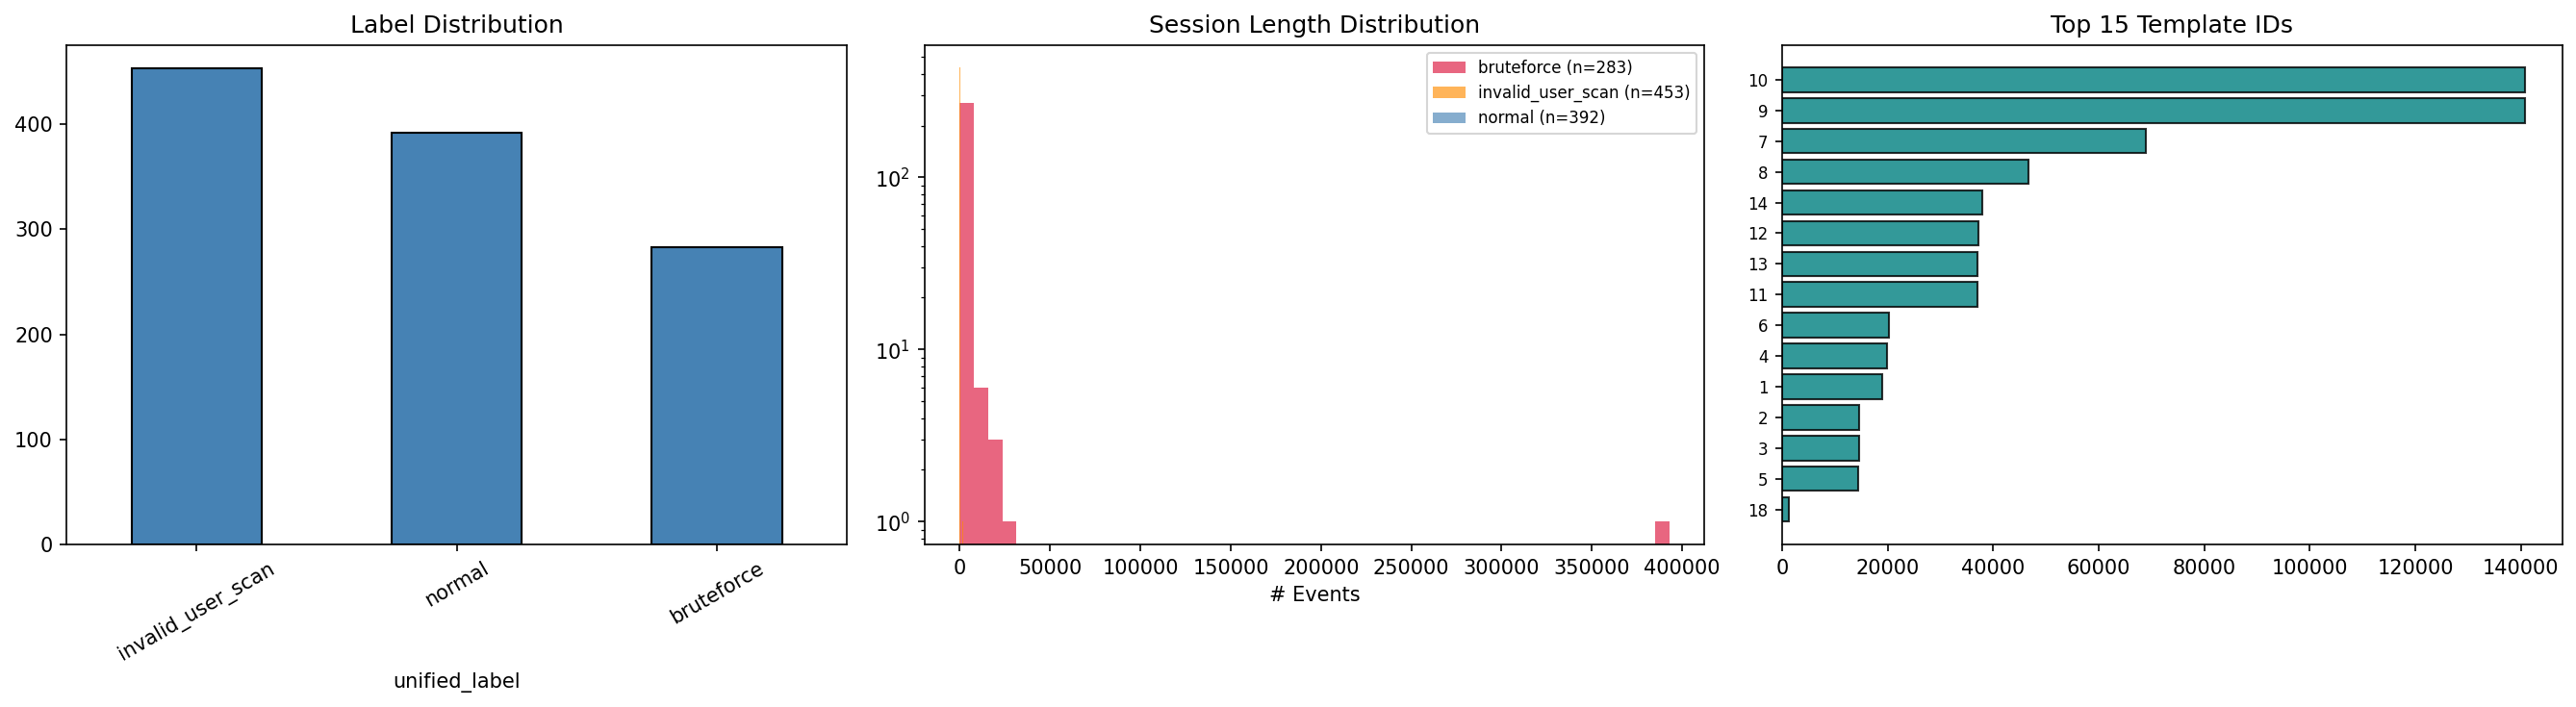

✓ EDA plots saved


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=150)

# Label dist
df_sessions['unified_label'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Label Distribution'); axes[0].tick_params(axis='x', rotation=30)

# Session length
colors = {'normal': 'steelblue', 'bruteforce': 'crimson', 'invalid_user_scan': 'darkorange'}
for label in ALL_CLASSES:
    subset = df_sessions[df_sessions['unified_label'] == label]['n_events']
    if len(subset) > 0:
        axes[1].hist(subset, bins=50, alpha=0.65,
                     label=f'{label} (n={len(subset):,})',
                     color=colors.get(label, 'gray'), edgecolor='none')
axes[1].set_yscale('log'); axes[1].set_title('Session Length Distribution')
axes[1].set_xlabel('# Events'); axes[1].legend(fontsize=8)

# Top templates
top15 = df_parsed['template_id'].value_counts().head(15)
axes[2].barh(range(len(top15)), top15.values, color='teal', edgecolor='black', alpha=0.8)
axes[2].set_yticks(range(len(top15)))
axes[2].set_yticklabels([str(t)[:30] for t in top15.index], fontsize=8)
axes[2].set_title('Top 15 Template IDs'); axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'eda_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ EDA plots saved')

## Step 10 — Build Model: CNN-BiLSTM-Attention (Functional API)

Using Keras Functional API instead of Sequential to support residual connections.

In [34]:
%%time

def build_auth_model(vocab_size, num_classes, max_seq_len, embed_dim=128):
    """
    CNN-BiLSTM-Attention model for SSH auth log sessions.

    Architecture:
      Embedding → [Conv1D(k=3) + Conv1D(k=5)] residual → BiLSTM(128)
      → MultiHeadAttention(4h) residual → GlobalAvgPool
      → Dense(256,gelu) → Dense(128,gelu) → Softmax(fp32)
    """
    inputs = Input(shape=(max_seq_len,), name='input_seq')

    # ── Embedding ─────────────────────────────────────────────────────────────
    x = Embedding(vocab_size + 1, embed_dim, mask_zero=True, name='embedding')(inputs)

    # ── Multi-kernel CNN (local burst detection) ───────────────────────────────
    cnn3 = Conv1D(128, kernel_size=3, padding='same', activation='gelu', name='cnn_k3')(x)
    cnn5 = Conv1D(128, kernel_size=5, padding='same', activation='gelu', name='cnn_k5')(x)
    # Project embedding to 128 dims for the residual add
    x_proj = Conv1D(128, kernel_size=1, padding='same', name='proj')(x)
    cnn_out = Add(name='cnn_add')([cnn3, cnn5])
    cnn_out = Add(name='cnn_residual')([cnn_out, x_proj])  # residual
    cnn_out = LayerNormalization(name='cnn_norm')(cnn_out)

    # ── BiLSTM (sequential order) ──────────────────────────────────────────────
    lstm_out = Bidirectional(
        LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.1),
        name='bilstm'
    )(cnn_out)

    # ── Multi-Head Attention (which events mattered?) ──────────────────────────
    attn_out, attn_weights = MultiHeadAttention(
        num_heads=4, key_dim=32, name='mha'
    )(lstm_out, lstm_out, return_attention_scores=True)
    attn_out = Add(name='attn_residual')([lstm_out, attn_out])   # residual
    attn_out = LayerNormalization(name='attn_norm')(attn_out)

    # ── Pooling ────────────────────────────────────────────────────────────────
    pooled = GlobalAveragePooling1D(name='global_pool')(attn_out)

    # ── Classifier ────────────────────────────────────────────────────────────
    x = Dense(256, activation='gelu', name='dense_1')(pooled)
    x = Dropout(0.4, name='drop_1')(x)
    x = Dense(128, activation='gelu', name='dense_2')(x)
    x = Dropout(0.3, name='drop_2')(x)
    # IMPORTANT: output must be float32 for mixed precision stability
    outputs = Dense(num_classes, activation='softmax',
                    dtype='float32', name='output')(x)

    return Model(inputs, outputs, name='Auth_CNN_BiLSTM_Attention')


model = build_auth_model(VOCAB_SIZE, NUM_CLASSES, MAX_SEQ_LEN)

# ── Compile with Focal Loss + gradient clipping ────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001,
        clipnorm=1.0           # prevents gradient explosion
    ),
    loss=FocalLoss(alpha=0.25, gamma=4.0),
    metrics=[
        'accuracy',
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top2_acc')
    ]
)

model.summary()
print(f'\nTotal params: {model.count_params():,}')

Model: "Auth_CNN_BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_seq           │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 128, 128)  │      6,272 │ input_seq[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_k3 (Conv1D)     │ (None, 128, 128)  │     49,280 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_k5 (Conv1D)     │ (None, 128, 128)  │     82,048 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_add (Add)       │ (None, 128, 128)  │          0 │ cnn_k3[0][0],     │
│                     │                   │            │ cnn_k5[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ proj (Conv1D)       │ (None, 128, 128)  │     16,512 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_residual (Add)  │ (None, 128, 128)  │          0 │ cnn_add[0][0],    │
│                     │                   │            │ proj[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_norm            │ (None, 128, 128)  │        256 │ cnn_residual[0][… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 128, 256)  │    263,168 │ cnn_norm[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha                 │ [(None, 128,      │    131,712 │ bilstm[0][0],     │
│ (MultiHeadAttentio… │ 256), (None, 4,   │            │ bilstm[0][0]      │
│                     │ 128, 128)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_residual (Add) │ (None, 128, 256)  │          0 │ bilstm[0][0],     │
│                     │                   │            │ mha[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_norm           │ (None, 128, 256)  │        512 │ attn_residual[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_pool         │ (None, 256)       │          0 │ attn_norm[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ global_pool[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_1 (Dropout)    │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ drop_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_2 (Dropout)    │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │        387 │ drop_2[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 648,835 (2.48 MB)

 Trainable params: 648,835 (2.48 MB)

 Non-trainable params: 0 (0.00 B)


Total params: 648,835
CPU times: user 134 ms, sys: 10.1 ms, total: 144 ms
Wall time: 135 ms


## Step 11 — Train

In [35]:
%%time

INITIAL_LR = 0.001
MAX_EPOCHS = 50

callbacks = [
    CosineAnnealingWarmRestarts(
        initial_lr=INITIAL_LR,
        T_0=10,       # first restart after 10 epochs
        T_mult=2,     # each subsequent cycle doubles in length
        eta_min=1e-6
    ),
    MacroF1EarlyStopping(
        X_val=X_test, y_val=y_test,
        patience=7, verbose=1
    ),
    tf.keras.callbacks.TensorBoard(
        log_dir=OUTPUT_PATH + 'tb_logs', histogram_freq=0
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=MAX_EPOCHS,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

print(f'\nTraining complete.')
print(f'Best val macro F1 achieved (from callback): check MacroF1EarlyStopping log above')

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - accuracy: 0.4054 - loss: 0.1359 - top2_acc: 0.7317  val_macro_f1: 0.4403  (best: 0.0000)
4/4 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.4361 - loss: 0.1288 - top2_acc: 0.7808 - val_accuracy: 0.5273 - val_loss: 0.0341 - val_top2_acc: 0.9318
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.4799 - loss: 0.0561 - top2_acc: 0.8770  val_macro_f1: 0.4703  (best: 0.4403)
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.4737 - loss: 0.0553 - top2_acc: 0.8836 - val_accuracy: 0.5182 - val_loss: 0.0322 - val_top2_acc: 0.9273
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.4858 - loss: 0.0439 - top2_acc: 0.9093  val_macro_f1: 0.4879  (best: 0.4703)
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.4920 - loss: 0.0435 - top2_acc: 0.9121 - val_accuracy: 0.5318 - val_loss: 0.0319 - val_top2_acc: 0.9273
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.5498 - loss: 0.0365 - top2_acc: 0.9213  val_macro_

## Step 12 — Evaluate

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
=== CLASSIFICATION REPORT ===
                   precision    recall  f1-score   support

       bruteforce       0.95      1.00      0.97        55
invalid_user_scan       1.00      0.97      0.98        88
           normal       1.00      1.00      1.00        77

         accuracy                           0.99       220
        macro avg       0.98      0.99      0.99       220
     weighted avg       0.99      0.99      0.99       220

Macro F1:    0.9854
Weighted F1: 0.9864


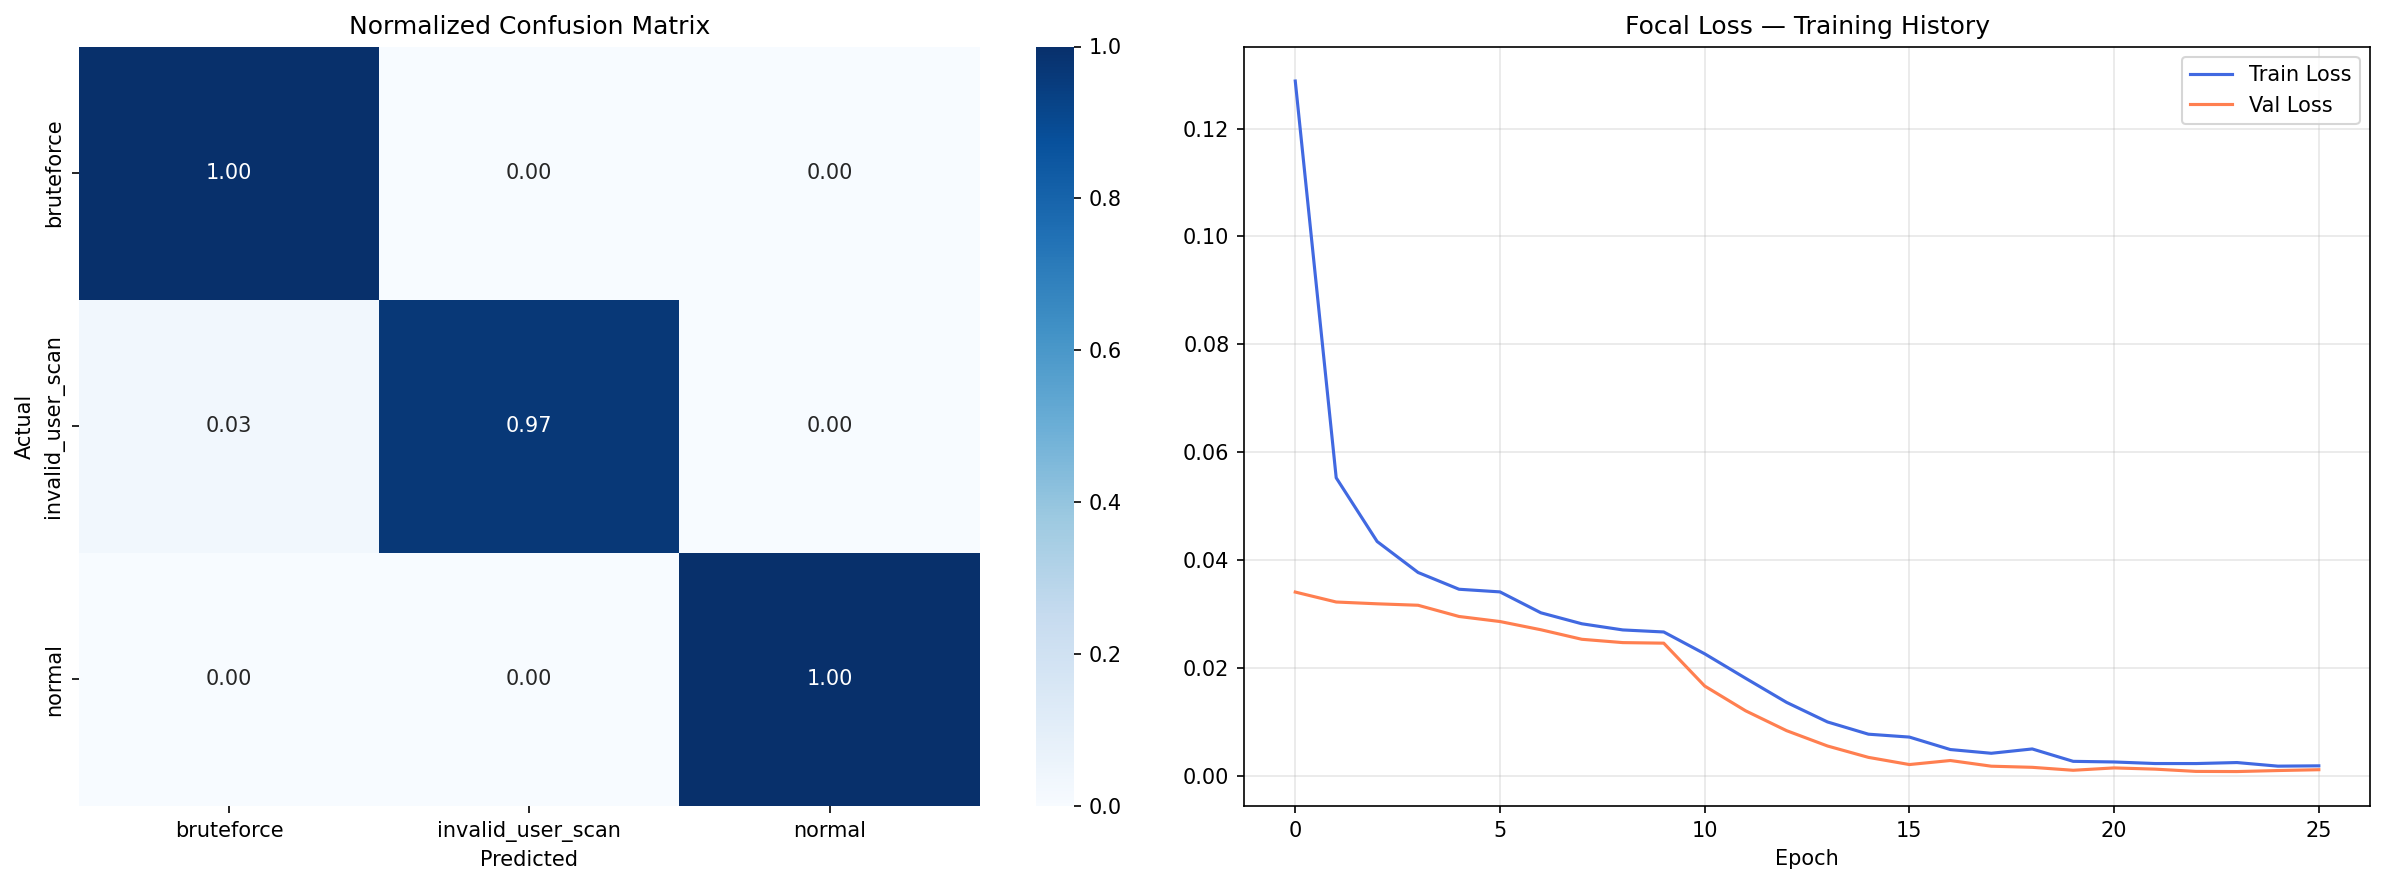

✓ confusion_matrix.png, training_history.png saved
CPU times: user 1.5 s, sys: 94.5 ms, total: 1.6 s
Wall time: 1.41 s


In [37]:
%%time

y_pred_probs = model.predict(X_test, batch_size=512)
y_pred = np.argmax(y_pred_probs, axis=1)

macro_f1    = f1_score(y_test, y_pred, average='macro',    zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print('=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred,
                             target_names=master_le.classes_, zero_division=0))
print(f'Macro F1:    {macro_f1:.4f}')
print(f'Weighted F1: {weighted_f1:.4f}')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, normalize='true')
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=150)

sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=master_le.classes_, yticklabels=master_le.classes_, ax=axes[0])
axes[0].set_title('Normalized Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# Training curves
if 'loss' in history.history:
    axes[1].plot(history.history['loss'],     label='Train Loss', color='royalblue')
    axes[1].plot(history.history['val_loss'], label='Val Loss',   color='coral')
    axes[1].set_title('Focal Loss — Training History')
    axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.savefig(OUTPUT_PATH + 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ confusion_matrix.png, training_history.png saved')

## Step 13 — Save Inference Holdout

In [38]:
%%time

# MITRE ATT&CK mappings
AUTH_MITRE_MAP = {
    'bruteforce': {
        'tactic': 'Credential Access', 'tactic_id': 'TA0006',
        'technique': 'Brute Force', 'technique_id': 'T1110',
        'kill_chain_stage': 2, 'kill_chain_name': 'Reconnaissance',
        'description': 'SSH brute force attack — repeated authentication failures from single IP.'
    },
    'invalid_user_scan': {
        'tactic': 'Discovery', 'tactic_id': 'TA0007',
        'technique': 'Account Discovery', 'technique_id': 'T1087',
        'kill_chain_stage': 2, 'kill_chain_name': 'Reconnaissance',
        'description': 'Username enumeration via SSH invalid user probing.'
    },
    'normal': {
        'tactic': None, 'tactic_id': None, 'technique': None, 'technique_id': None,
        'kill_chain_stage': 0, 'kill_chain_name': 'No Threat',
        'description': 'Normal SSH activity.'
    }
}

inf_probs = model.predict(X_inf, batch_size=256, verbose=0)
inf_preds = np.argmax(inf_probs, axis=1)
inf_confs = np.max(inf_probs, axis=1)

results = []
for i, (_, session) in enumerate(df_inference.iterrows()):
    pred_class = master_le.classes_[inf_preds[i]]
    true_class = session['unified_label']
    conf_pct   = round(float(inf_confs[i]) * 100, 2)
    src_ip     = str(session['session_id'])
    alert_id   = f'AUTH-{src_ip}'
    is_attack  = pred_class != 'normal'
    mitre      = AUTH_MITRE_MAP.get(pred_class, AUTH_MITRE_MAP['normal'])

    results.append({
        'id': alert_id, 'block_id': alert_id, 'session_key': src_ip,
        'source': SOURCE_NAME, 'src_ip': src_ip,
        'prediction': 'Anomaly' if is_attack else 'Normal',
        'verdict': 'ATTACK' if is_attack else 'NORMAL',
        'attack_type': pred_class if is_attack else None,
        'confidence': conf_pct,
        'n_events': int(session['n_events']),
        'true_label': true_class, 'is_correct': pred_class == true_class,
        'preview': f'SSH | IP: {src_ip} | Events: {session["n_events"]}',
        'label': 'Anomaly' if is_attack else 'Normal',
        'title': f'{pred_class.upper()} Detected' if is_attack else 'Normal SSH Activity',
        'severity': 'critical' if conf_pct > 85 else ('warning' if is_attack else 'info'),
        'time': datetime.datetime.utcnow().isoformat(),
        'event_count': int(session['n_events']),
        'mitre': mitre
    })

# Save all files
with open(OUTPUT_PATH + 'inference_samples.txt', 'w', encoding='utf-8') as f:
    for _, session in df_inference.iterrows():
        for raw_line in session['raw_lines']:
            f.write(str(raw_line) + '\n')

df_inference[['session_id', 'unified_label', 'n_events']].to_csv(
    OUTPUT_PATH + 'inference_labels.csv', index=False)

with open(OUTPUT_PATH + 'inference_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f'✓ inference_results.json — {len(results)} sessions')
print(f'  Accuracy: {sum(r["is_correct"] for r in results)}/{len(results)}')

✓ inference_results.json — 32 sessions
  Accuracy: 30/32
CPU times: user 357 ms, sys: 61.7 ms, total: 419 ms
Wall time: 220 ms


## Step 14 — Save Model and Model Card

In [ ]:
%%time

model.save(OUTPUT_PATH + 'bilstm_model.keras')
print('✓ bilstm_model.keras saved')

model_card = {
    'model_name': 'Auth Log — CNN-BiLSTM-Attention (v2)',
    'source': SOURCE_NAME, 'version': '2.0.0',
    'created': datetime.datetime.utcnow().isoformat(),
    'dataset': 'LogHub SSH (omduggineni/loghub-ssh-log-data)',
    'labeling': 'SSH logs self-announce attack type (kernel-level messages)',
    'architecture': {
        'name': 'CNN-BiLSTM-MultiHeadAttention',
        'embedding_dim': 128,
        'cnn_kernels': [3, 5],
        'bilstm_units': 128,
        'attention_heads': 4,
        'attention_key_dim': 32,
        'dense_units': [256, 128],
        'activations': 'gelu',
        'dropout': [0.4, 0.3]
    },
    'training': {
        'loss': 'FocalLoss(alpha=0.25, gamma=2.0)',
        'optimizer': 'Adam(clipnorm=1.0)',
        'lr_schedule': 'CosineAnnealingWarmRestarts(T_0=10, T_mult=2)',
        'early_stopping': 'MacroF1EarlyStopping(patience=7)',
        'mixed_precision': 'mixed_float16'
    },
    'vocab_size': VOCAB_SIZE, 'num_classes': NUM_CLASSES,
    'classes': list(master_le.classes_), 'max_seq_len': MAX_SEQ_LEN,
    'session_method': 'Grouped by source IP (each unique IP = one session)',
    'performance': {'macro_f1': round(float(macro_f1), 4), 'weighted_f1': round(float(weighted_f1), 4)},
    'output_format': {
        'id': 'AUTH-{src_ip}', 'block_id': 'same as id', 'source': SOURCE_NAME,
        'prediction': 'Normal or Anomaly', 'verdict': 'NORMAL or ATTACK',
        'attack_type': 'None | bruteforce | invalid_user_scan',
        'confidence': 'float 0-100', 'mitre': 'dict with kill_chain_stage and kill_chain_name'
    }
}

with open(OUTPUT_PATH + 'model_card.json', 'w') as f:
    json.dump(model_card, f, indent=2)

# ── Verification ──────────────────────────────────────────────────────────────
artifacts = ['bilstm_model.keras', 'vocab.pkl', 'label_encoder.pkl',
             'feature_names.txt', 'label_map.json', 'model_card.json',
             'inference_samples.txt', 'inference_labels.csv', 'inference_results.json']
print('\n=== ARTIFACT VERIFICATION ===')
for fname in artifacts:
    p = OUTPUT_PATH + fname
    ok = os.path.exists(p)
    sz = os.path.getsize(p)/1024 if ok else 0
    print(f'  {"✓" if ok else "✗"} {fname:40s} {sz:.1f} KB')

with open(OUTPUT_PATH + 'inference_results.json') as f:
    chk = json.load(f)
req_keys = ['id','block_id','session_key','source','prediction','verdict','attack_type',
            'confidence','n_events','mitre','title','severity','time']
missing = [k for k in req_keys if k not in chk[0]]
mitre_keys = ['kill_chain_stage','kill_chain_name','technique_id']
missing_m = [k for k in mitre_keys if k not in chk[0]['mitre']]
confs = [r['confidence'] for r in chk]
print(f'\n=== INTEGRATION CHECK ===')
print(f'Missing keys:      {missing or "None"}')
print(f'Missing MITRE:     {missing_m or "None"}')
print(f'Confidence range:  {min(confs):.1f}–{max(confs):.1f}  (expected 0-100)')
print(f'Macro F1:          {macro_f1:.4f}')
print(f'\n✓ auth_log model ready for backend integration.')